# CardioLens-IoT — Training and Evaluation Notebook

**Explainable 12-lead ECG image classification for IoT-based cardiac monitoring.**

This notebook trains and evaluates the ECG analysis module of CardioLens-IoT: a fine-tuned **EfficientNetB0** that classifies 12-lead ECG images into four classes:

| Label | Class |
|---|---|
| AHB | Abnormal heartbeat |
| PMI | History of myocardial infarction |
| MI | Myocardial infarction |
| Normal | Normal ECG |

**Key design choice:** the data are split into train / validation / test **before** augmentation, and only the training set is augmented. Validation and test sets contain only original, unseen images, so the reported accuracy reflects real generalization.

**Contents**

0. Setup and configuration
1. Data loading
2. Leak-free data split
3. Training-set augmentation
4. Model architecture
5. Two-phase training
6. Test-set evaluation
7. Figures (dataset, training, performance, explainability)
8. Deployment metrics for the IoT cloud layer
9. Export of results

**Runtime:** Kaggle GPU (T4 x2), about 20 minutes. **Dataset:** [ECG Images Dataset of Cardiac Patients](https://doi.org/10.17632/gwbz3fsgp8.2), added as a Kaggle input. For a local run, place the class folders under `data/raw/` (see `data/README.md`).

## 0. Setup and configuration

Imports, global settings and reproducibility. Mixed precision (float16) is enabled automatically when a GPU is available. All figures are saved at 300 dpi to `figures/`.

In [1]:
import os, time, json, hashlib, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             roc_auc_score, precision_recall_fscore_support, cohen_kappa_score)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE

# Paths: Kaggle by default, local folders otherwise
ON_KAGGLE   = os.path.exists("/kaggle/input")
DATA_ROOT   = "/kaggle/input" if ON_KAGGLE else "data/raw"
OUT_DIR     = "/kaggle/working" if ON_KAGGLE else "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
FIG_DIR     = os.path.join(OUT_DIR, "figures")
IMG_SIZE    = 384
BATCH_SIZE  = 32
SEED        = 42
AUG_COPIES  = 3
CLASS_NAMES = ["Abnormal_Heartbeat", "MI_history", "Myocardial_Infarction", "Normal"]
SHORT_NAMES = ["AHB", "PMI", "MI", "Normal"]          # short labels for plots
os.makedirs(FIG_DIR, exist_ok=True)

keras.utils.set_random_seed(SEED)
if tf.config.list_physical_devices("GPU"):
    keras.mixed_precision.set_global_policy("mixed_float16")

plt.rcParams.update({"font.size": 11, "font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False})
def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=300, bbox_inches="tight")
    plt.show()
RESULTS = {}

## 1. Data loading

Walks the dataset folders, maps each folder name to one of the four classes, and loads every image resized to **384 × 384 RGB** (anti-aliased). Expected result: 928 images (AHB 233, PMI 172, MI 239, Normal 284).

In [2]:
# Load every image and its class label
def folder_to_class(name):
    n = name.lower()
    if "history" in n:                          return "MI_history"
    if "abnormal" in n:                         return "Abnormal_Heartbeat"
    if "myocardial" in n or "infarction" in n:  return "Myocardial_Infarction"
    if "normal" in n:                           return "Normal"
    return None

paths, labels = [], []
for root, _, files in os.walk(DATA_ROOT):
    cls = folder_to_class(os.path.basename(root))
    if cls:
        for f in sorted(files):
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(root, f))
                labels.append(CLASS_NAMES.index(cls))
paths = np.array(paths)

def load(path):
    img = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    return tf.cast(tf.clip_by_value(tf.image.resize(img, (IMG_SIZE, IMG_SIZE), antialias=True), 0, 255), tf.uint8).numpy()

X_all = np.stack([load(p) for p in paths])
y_all = np.array(labels)
print("Original images:", X_all.shape, "| per class:", np.bincount(y_all))

I0000 00:00:1790392133.815486      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790392133.818577      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Original images: (928, 384, 384, 3) | per class: [233 172 239 284]


## 2. Leak-free data split

The 928 **original** images are split with stratification into training (70%), validation (15%) and test (15%) sets. Splitting happens **before** any augmentation, and an assertion guarantees the three sets do not overlap.

> Why this matters: if augmentation is done first, shifted or zoomed copies of the same ECG land in both training and test sets, and the test measures memorization. In a controlled experiment with the same model, augmenting first raised test accuracy from 93.57% to 98.74%.

In [3]:
# Stratified 70 / 15 / 15 split on the original images only
idx = np.arange(len(y_all))
tr_idx, tmp_idx = train_test_split(idx, test_size=0.30, stratify=y_all, random_state=SEED)
va_idx, te_idx  = train_test_split(tmp_idx, test_size=0.50, stratify=y_all[tmp_idx], random_state=SEED)
assert not (set(tr_idx) & set(va_idx) or set(tr_idx) & set(te_idx) or set(va_idx) & set(te_idx))


X_train, y_train = X_all[tr_idx], y_all[tr_idx]
X_val,   y_val   = X_all[va_idx], y_all[va_idx]
X_test,  y_test  = X_all[te_idx], y_all[te_idx]
print(f"Train: {len(y_train)} | Validation: {len(y_val)} | Test: {len(y_test)}")

Train: 649 | Validation: 139 | Test: 140


## 3. Training-set augmentation

Three augmented copies of every **training** image are created (translation ±5%, zoom ±10%, rotation ≈ ±7°, contrast ±20%). Empty regions are filled with white to match ECG paper. The training set grows from 649 to 2,596 images; validation and test sets are untouched.

In [4]:
# Offline augmentation of the training set only
augment = keras.Sequential([
    layers.RandomTranslation(0.05, 0.05, fill_mode="constant", fill_value=255.0),
    layers.RandomZoom(0.1, fill_mode="constant", fill_value=255.0),
    layers.RandomRotation(0.02, fill_mode="constant", fill_value=255.0),
    layers.RandomContrast(0.2),
])

copies = []
for _ in range(AUG_COPIES):
    for i in range(0, len(X_train), 64):
        batch = augment(tf.cast(X_train[i:i + 64], tf.float32), training=True)
        copies.append(tf.cast(tf.clip_by_value(batch, 0, 255), tf.uint8).numpy())

X_train_orig = X_train.copy()                       # kept for the figures
X_train = np.concatenate([X_train] + copies)
y_train = np.concatenate([y_train] * (AUG_COPIES + 1))
print("Training set after augmentation:", X_train.shape)

Training set after augmentation: (2596, 384, 384, 3)


## 4. Model architecture

EfficientNetB0 pretrained on ImageNet, followed by global average pooling, dropout (0.3) and a 4-class softmax. Light on-the-fly augmentation layers are active only during training. Total parameters: about 4.05 million.

In [5]:
# EfficientNetB0 backbone + classification head
base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

inputs  = keras.Input((IMG_SIZE, IMG_SIZE, 3))
x       = layers.Rescaling(1.0)(inputs)
x       = layers.RandomTranslation(0.03, 0.03, fill_mode="constant", fill_value=255.0)(x)
x       = layers.RandomZoom(0.05, fill_mode="constant", fill_value=255.0)(x)
x       = layers.RandomContrast(0.15)(x)
x       = base(x, training=False)
x       = layers.GlobalAveragePooling2D(name="gap")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32", name="classifier")(x)
model   = keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 5. Two-phase training

* **Phase 1** — backbone frozen, only the head is trained (Adam, learning rate 1e-3, up to 20 epochs).
* **Phase 2** — the top 60 backbone layers are unfrozen and fine-tuned (Adam, learning rate 1e-4, up to 40 epochs). Batch-normalization layers stay frozen.

Both phases use balanced class weights, early stopping on validation loss (patience 6, best weights restored) and learning-rate reduction on plateau. The trained model is saved as `ecg_efficientnetb0.keras`.

In [6]:
# Phase 1: train the head; Phase 2: fine-tune the top of the backbone
Y_train = keras.utils.to_categorical(y_train, len(CLASS_NAMES))
Y_val   = keras.utils.to_categorical(y_val, len(CLASS_NAMES))
class_weight = dict(enumerate(compute_class_weight("balanced", classes=np.arange(len(CLASS_NAMES)), y=y_train)))

def fit(lr, epochs, initial_epoch=0):
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="categorical_crossentropy", metrics=["accuracy"])
    return model.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=BATCH_SIZE,
                     epochs=epochs, initial_epoch=initial_epoch, class_weight=class_weight,
                     callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
                                keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3)])

t0 = time.time()
h1 = fit(1e-3, 20)

base.trainable = True
for layer in base.layers[:-60]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

start = len(h1.history["loss"])
h2 = fit(1e-4, start + 40, initial_epoch=start)
RESULTS["training_time_min"] = round((time.time() - t0) / 60, 2)

history = {k: h1.history[k] + h2.history[k] for k in ["loss", "val_loss", "accuracy", "val_accuracy"]}
FT_START = start
model.save(os.path.join(OUT_DIR, "ecg_efficientnetb0.keras"))

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 77s 534ms/step - accuracy: 0.4472 - loss: 1.2194 - val_accuracy: 0.6187 - val_loss: 1.0685 - learning_rate: 0.0010
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.5470 - loss: 1.0357 - val_accuracy: 0.6403 - val_loss: 0.9748 - learning_rate: 0.0010
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.5905 - loss: 0.9673 - val_accuracy: 0.7050 - val_loss: 0.9265 - learning_rate: 0.0010
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.6009 - loss: 0.9207 - val_accuracy: 0.6978 - val_loss: 0.9014 - learning_rate: 0.0010
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.6337 - loss: 0.8862 - val_accuracy: 0.7122 - val_loss: 0.8732 - learning_rate: 0.0010
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step - accuracy: 0.6402 - loss: 0.8655 - val_accuracy: 0.6978 - val_loss: 0.8651 - learning_rate: 0.0010
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.6549 - loss: 0.

## 6. Test-set evaluation

The held-out test set (140 original images) is used **once**, after training. Reported metrics: accuracy, per-class precision, recall (sensitivity), specificity and F1-score, macro AUC (one-vs-rest) and Cohen's kappa.

In [7]:
# Evaluate on the held-out test set
probs  = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred = probs.argmax(axis=1)

acc = (y_pred == y_test).mean()
p, r, f1, sup = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)
spec = [(cm.sum() - cm[i].sum() - cm[:, i].sum() + cm[i, i]) / (cm.sum() - cm[i].sum()) for i in range(len(CLASS_NAMES))]
auc_macro = roc_auc_score(label_binarize(y_test, classes=range(len(CLASS_NAMES))), probs, average="macro")

print(f"Test accuracy: {acc:.2%}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

RESULTS.update({
    "n_images": int(len(y_all)), "per_class_counts": np.bincount(y_all).tolist(),
    "split_sizes": {"train_original": int(len(tr_idx)), "train_after_aug": int(len(y_train)),
                    "val": int(len(y_val)), "test": int(len(y_test))},
    "test_accuracy": float(acc), "macro_f1": float(f1.mean()), "macro_auc": float(auc_macro),
    "cohen_kappa": float(cohen_kappa_score(y_test, y_pred)),
    "per_class": {c: {"precision": float(p[i]), "recall_sensitivity": float(r[i]), "specificity": float(spec[i]),
                      "f1": float(f1[i]), "support": int(sup[i])} for i, c in enumerate(CLASS_NAMES)},
    "confusion_matrix": cm.tolist(), "epochs_total": len(history["loss"]), "fine_tune_start_epoch": FT_START,
})

Test accuracy: 93.57%

                       precision    recall  f1-score   support

   Abnormal_Heartbeat      0.919     0.971     0.944        35
           MI_history      0.885     0.885     0.885        26
Myocardial_Infarction      0.947     1.000     0.973        36
               Normal      0.974     0.884     0.927        43

             accuracy                          0.936       140
            macro avg      0.931     0.935     0.932       140
         weighted avg      0.937     0.936     0.935       140



## 7. Figures

All figures are saved at 300 dpi to `figures/` and are the ones used in the paper and the README.

### 7.1 Class distribution
Number of images per class in the original dataset and in the augmented training set.

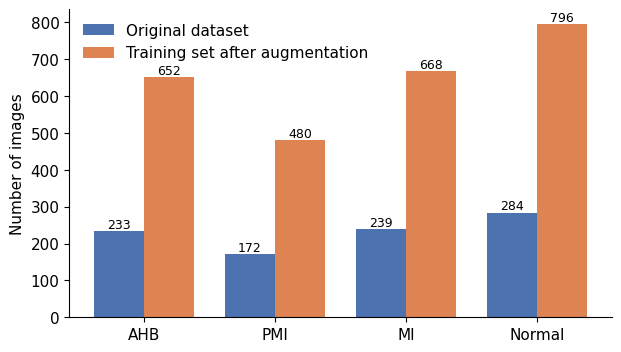

In [8]:
# Class distribution: original dataset vs. augmented training set
fig, ax = plt.subplots(figsize=(7, 4))
w = 0.38; xs = np.arange(len(CLASS_NAMES))
b1 = ax.bar(xs - w/2, np.bincount(y_all), w, label="Original dataset", color="#4C72B0")
b2 = ax.bar(xs + w/2, np.bincount(y_train), w, label="Training set after augmentation", color="#DD8452")
ax.bar_label(b1, fontsize=9); ax.bar_label(b2, fontsize=9)
ax.set_xticks(xs, SHORT_NAMES); ax.set_ylabel("Number of images"); ax.legend(frameon=False)
savefig("fig_class_distribution")

### 7.2 Sample images
Three random ECG images from each class.

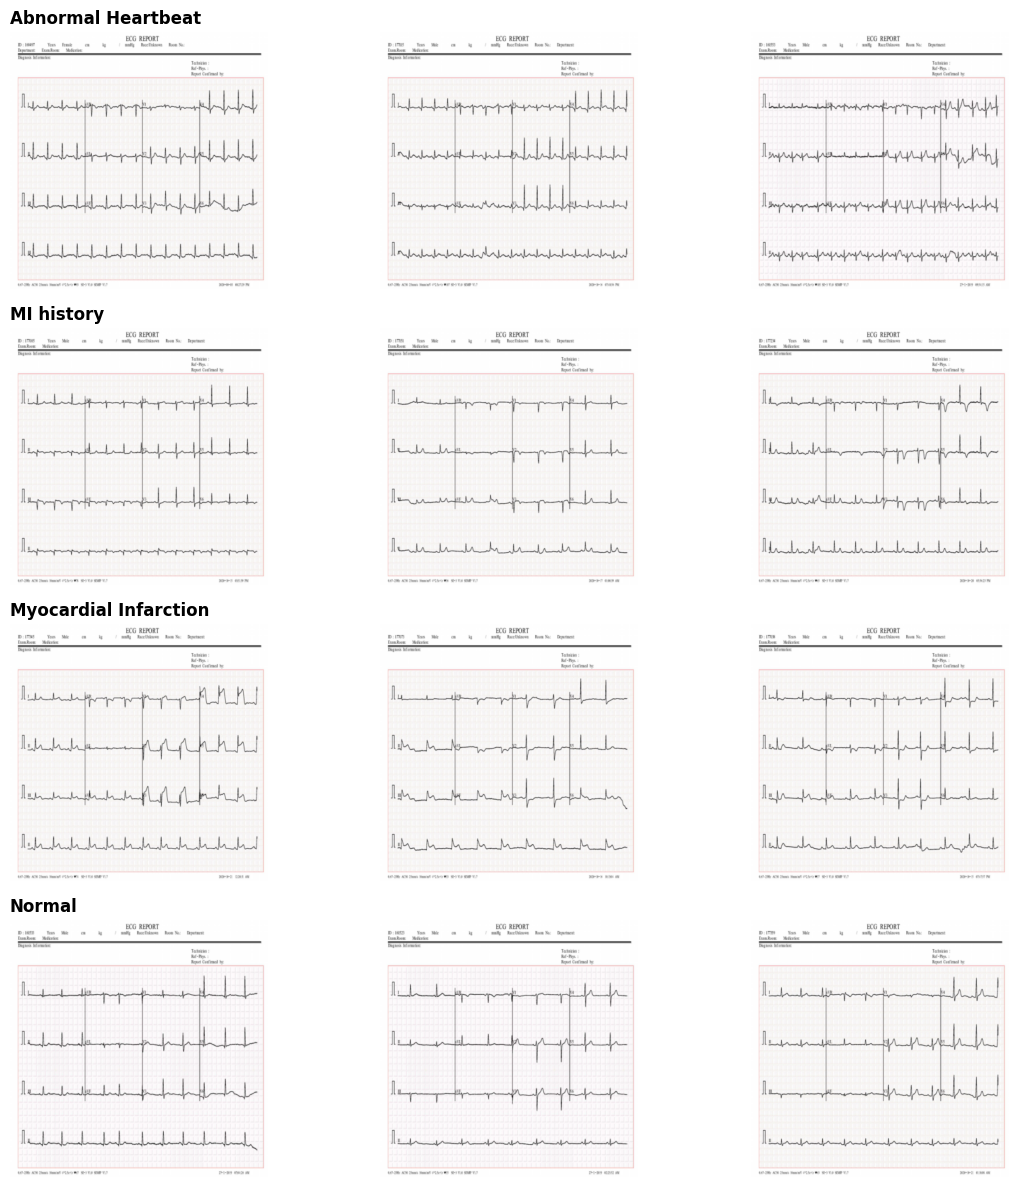

In [9]:
# Sample ECG images from each class
fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(12, 12))
rng = np.random.default_rng(SEED)
for i, c in enumerate(CLASS_NAMES):
    for j, k in enumerate(rng.choice(np.where(y_all == i)[0], 3, replace=False)):
        axes[i, j].imshow(X_all[k]); axes[i, j].axis("off")
    axes[i, 0].set_title(c.replace("_", " "), loc="left", fontsize=12, fontweight="bold")
plt.tight_layout(); savefig("fig_sample_images")

### 7.3 Augmentation examples
One original training image next to three augmented versions.

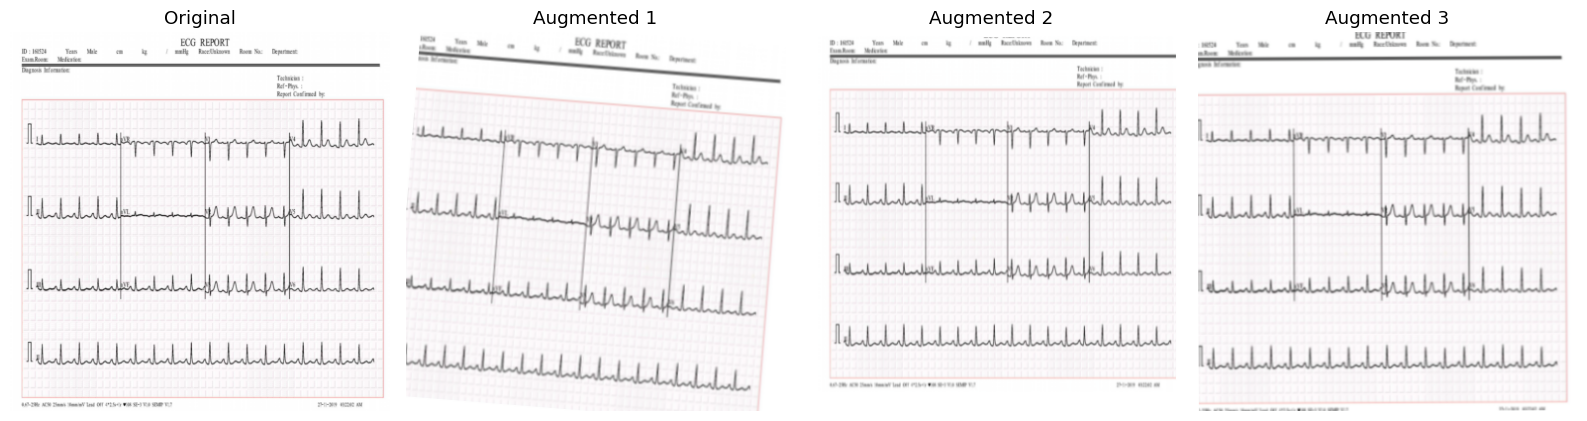

In [10]:
# One original training image and its augmented versions
k = 0
fig, axes = plt.subplots(1, AUG_COPIES + 1, figsize=(16, 4.5))
axes[0].imshow(X_train_orig[k]); axes[0].set_title("Original")
for j in range(AUG_COPIES):
    aug = augment(tf.cast(X_train_orig[k:k+1], tf.float32), training=True)
    axes[j + 1].imshow(tf.cast(tf.clip_by_value(aug, 0, 255), tf.uint8)[0]); axes[j + 1].set_title(f"Augmented {j+1}")
for a in axes: a.axis("off")
plt.tight_layout(); savefig("fig_augmentation_examples")

### 7.4 Training curves
Accuracy and loss for both phases; the dashed line marks the start of fine-tuning.

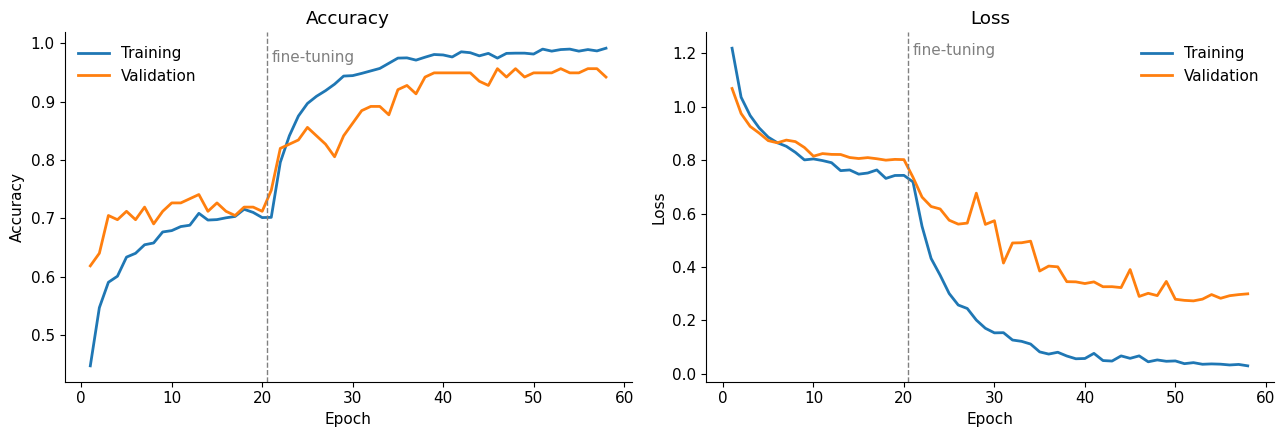

In [11]:
# Training and validation accuracy / loss
ep = np.arange(1, len(history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, key, title in [(axes[0], "accuracy", "Accuracy"), (axes[1], "loss", "Loss")]:
    ax.plot(ep, history[key], label="Training", lw=2)
    ax.plot(ep, history["val_" + key], label="Validation", lw=2)
    ax.axvline(FT_START + 0.5, color="gray", ls="--", lw=1)
    ax.text(FT_START + 1, ax.get_ylim()[1] * 0.97, "fine-tuning", color="gray", va="top")
    ax.set_xlabel("Epoch"); ax.set_ylabel(title); ax.set_title(title); ax.legend(frameon=False)
plt.tight_layout(); savefig("fig_training_curves")

### 7.5 Confusion matrix
Test-set predictions as counts and row-normalized rates.

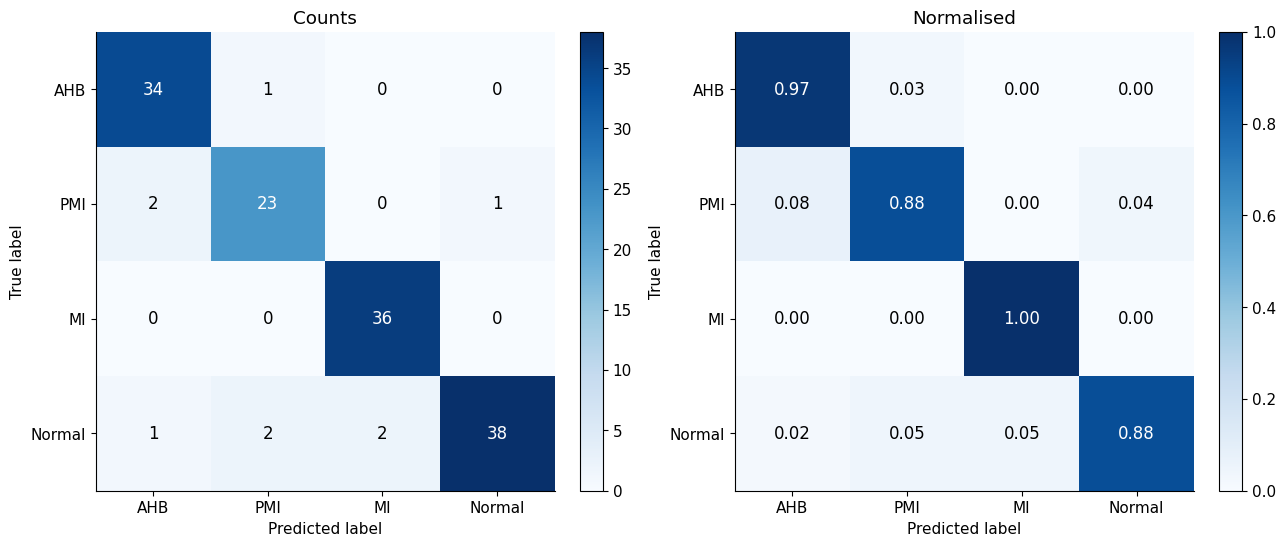

In [12]:
# Confusion matrix (counts and row-normalized)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, M, fmt, title in [(axes[0], cm, "d", "Counts"),
                          (axes[1], cm / cm.sum(axis=1, keepdims=True), ".2f", "Normalised")]:
    im = ax.imshow(M, cmap="Blues")
    for i in range(len(M)):
        for j in range(len(M)):
            ax.text(j, i, format(M[i, j], fmt), ha="center", va="center",
                    color="white" if M[i, j] > M.max() / 2 else "black", fontsize=12)
    ax.set_xticks(range(len(M)), SHORT_NAMES); ax.set_yticks(range(len(M)), SHORT_NAMES)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label"); ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); savefig("fig_confusion_matrix")

### 7.6 ROC curves
One-vs-rest ROC curve and AUC for each class.

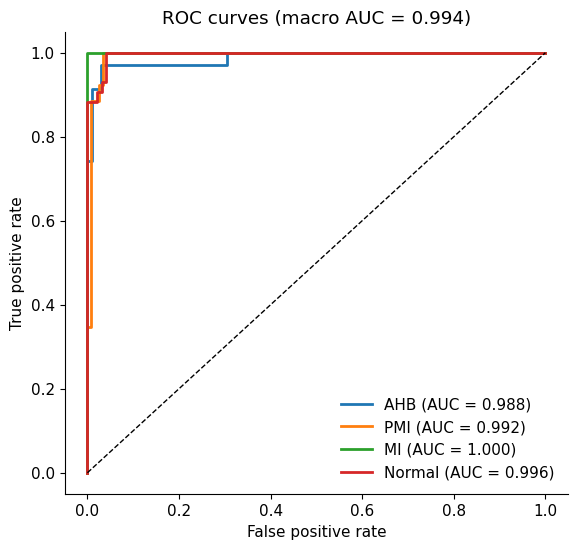

In [13]:
# One-vs-rest ROC curves
Yb = label_binarize(y_test, classes=range(len(CLASS_NAMES)))
fig, ax = plt.subplots(figsize=(6.5, 6))
for i, c in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(Yb[:, i], probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f"{SHORT_NAMES[i]} (AUC = {roc_auc_score(Yb[:, i], probs[:, i]):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curves (macro AUC = {auc_macro:.3f})"); ax.legend(frameon=False, loc="lower right")
savefig("fig_roc_curves")

### 7.7 Per-class metrics
Precision, recall, specificity and F1-score for each class.

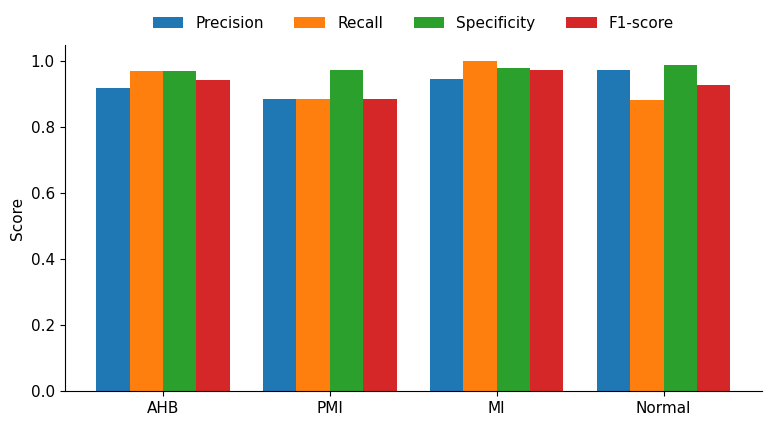

In [14]:
# Per-class precision / recall / specificity / F1
fig, ax = plt.subplots(figsize=(9, 4.5))
w = 0.2; xs = np.arange(len(CLASS_NAMES))
for k, (vals, name) in enumerate([(p, "Precision"), (r, "Recall"), (spec, "Specificity"), (f1, "F1-score")]):
    ax.bar(xs + (k - 1.5) * w, vals, w, label=name)
ax.set_xticks(xs, SHORT_NAMES); ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.legend(frameon=False, ncol=4, loc="lower center", bbox_to_anchor=(0.5, 1.0))
savefig("fig_per_class_metrics")

### 7.8 Explainability: Grad-CAM
Heatmaps of the image regions that drove each prediction, for one test image per class. In the IoT cloud, the same explanation is attached to every alert so a physician can check it.

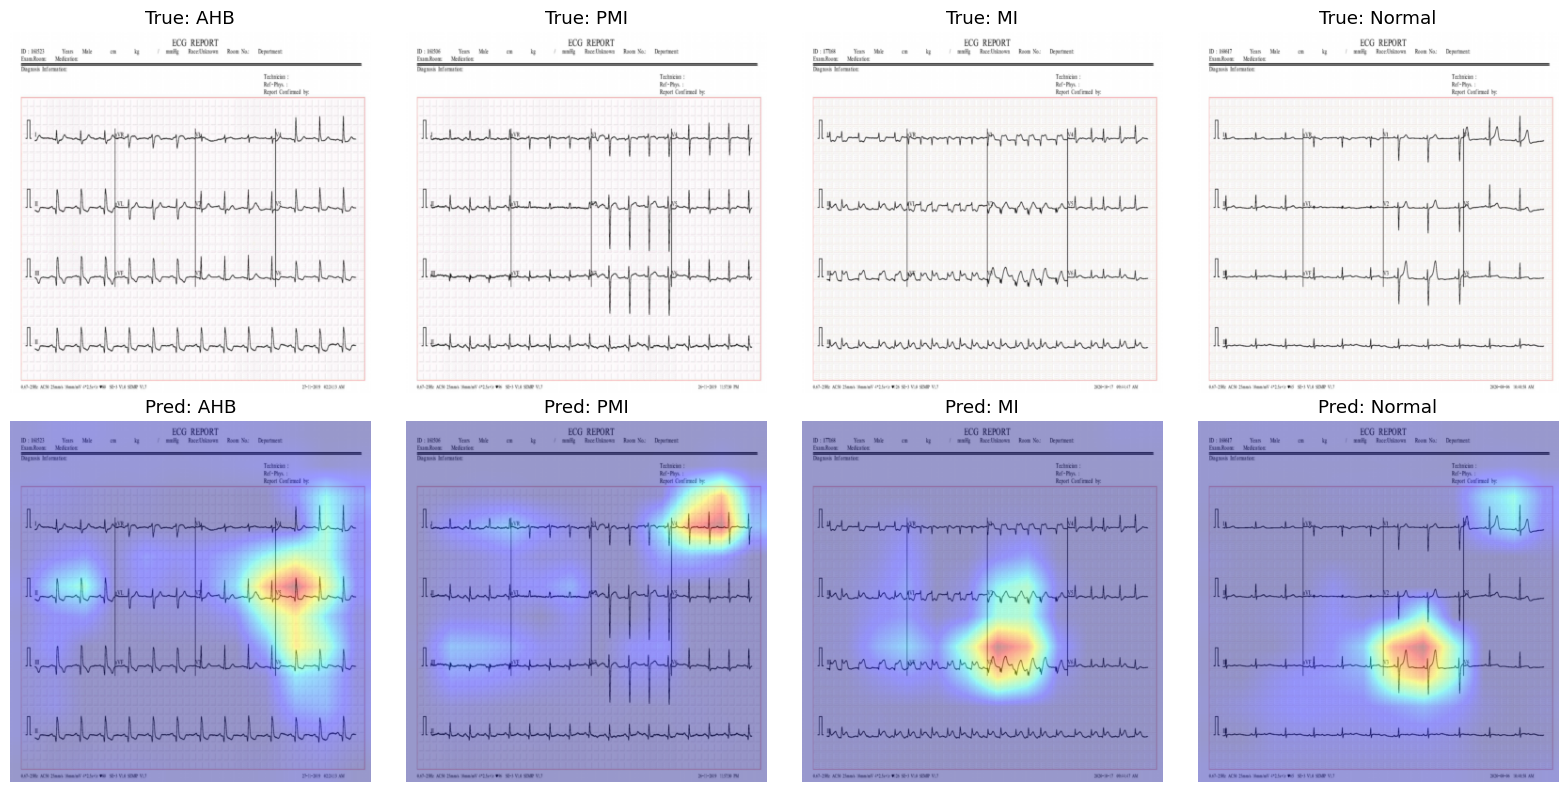

In [15]:
# Grad-CAM: which regions of the ECG drive each prediction
gap_layer, dense_layer = model.get_layer("gap"), model.get_layer("classifier")

def gradcam(img):
    x = tf.convert_to_tensor(img[None], tf.float32)
    with tf.GradientTape() as tape:
        conv = tf.cast(base(x, training=False), tf.float32)
        tape.watch(conv)
        pr = dense_layer(gap_layer(conv))
        cls = int(tf.argmax(pr[0]))
        score = pr[:, cls]
    g = tape.gradient(score, conv)
    cam = tf.nn.relu(tf.reduce_sum(conv * tf.reduce_mean(g, axis=(1, 2))[:, None, None, :], -1))[0]
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return tf.image.resize(cam[..., None], (IMG_SIZE, IMG_SIZE)).numpy()[..., 0], cls

fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(16, 8))
for i in range(len(CLASS_NAMES)):
    k = np.where(y_test == i)[0][0]
    cam, cls = gradcam(X_test[k])
    axes[0, i].imshow(X_test[k]); axes[0, i].set_title(f"True: {SHORT_NAMES[i]}")
    axes[1, i].imshow(X_test[k]); axes[1, i].imshow(cam, cmap="jet", alpha=0.4)
    axes[1, i].set_title(f"Pred: {SHORT_NAMES[cls]}")
for a in axes.ravel(): a.axis("off")
plt.tight_layout(); savefig("fig_gradcam")

### 7.9 Feature space: t-SNE
2-D projection of the 1,280-dimensional features the model learned, for the test images.

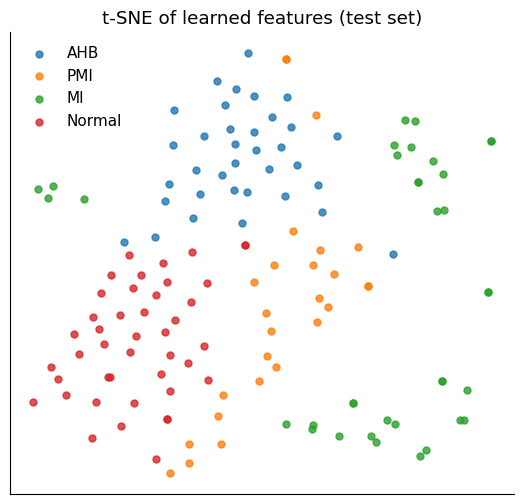

In [16]:
# t-SNE of the learned features (test set)
feat_model = keras.Model(model.input, model.get_layer("gap").output)
feats = feat_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).astype("float32")
emb = TSNE(n_components=2, perplexity=min(30, len(feats) // 4), random_state=SEED).fit_transform(feats)
fig, ax = plt.subplots(figsize=(6.5, 6))
for i in range(len(CLASS_NAMES)):
    m = y_test == i
    ax.scatter(emb[m, 0], emb[m, 1], s=25, label=SHORT_NAMES[i], alpha=0.8)
ax.set_xticks([]); ax.set_yticks([]); ax.legend(frameon=False)
ax.set_title("t-SNE of learned features (test set)")
savefig("fig_tsne")

## 8. Deployment metrics for the IoT cloud layer

Model size and single-image inference time, relevant for running the model in the IoT cloud. The timing uses unbatched, eager-mode calls and includes framework overhead, so batched or optimized serving is faster.

In [17]:
# Parameters, saved model size and single-image inference time
RESULTS["params_total"] = int(model.count_params())
RESULTS["keras_model_MB"] = round(os.path.getsize(os.path.join(OUT_DIR, "ecg_efficientnetb0.keras")) / 1e6, 2)

one = tf.convert_to_tensor(X_test[:1], tf.float32)
for _ in range(5): model(one, training=False)          # warm-up
t0 = time.perf_counter()
for _ in range(50): model(one, training=False).numpy()
RESULTS["inference_ms_per_image"] = round((time.perf_counter() - t0) / 50 * 1000, 2)
RESULTS["device"] = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print({k: RESULTS[k] for k in ("params_total", "keras_model_MB", "inference_ms_per_image", "device")})

{'params_total': 4054695, 'keras_model_MB': 59.59, 'inference_ms_per_image': 362.47, 'device': 'GPU'}


## 9. Export of results

Writes all metrics to `results.json` and zips the figures into `figures.zip` for download.

In [18]:
# Save metrics and package the figures
print("1. saving results.json ...")
with open(os.path.join(OUT_DIR, "results.json"), "w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
print("2. zipping figures ...", os.listdir(FIG_DIR))
shutil.make_archive(os.path.join(OUT_DIR, "figures"), "zip", FIG_DIR)
print("3. done:", os.listdir(OUT_DIR))
print(json.dumps(RESULTS, indent=2, default=float))

1. saving results.json ...
2. zipping figures ... ['fig_gradcam.png', 'fig_training_curves.png', 'fig_per_class_metrics.png', 'fig_confusion_matrix.png', 'fig_tsne.png', 'fig_roc_curves.png', 'fig_sample_images.png', 'fig_augmentation_examples.png', 'fig_class_distribution.png']
3. done: ['figures.zip', '.virtual_documents', 'results.json', 'figures', 'ecg_efficientnetb0.keras']
{
  "training_time_min": 17.35,
  "n_images": 928,
  "per_class_counts": [
    233,
    172,
    239,
    284
  ],
  "split_sizes": {
    "train_original": 649,
    "train_after_aug": 2596,
    "val": 139,
    "test": 140
  },
  "test_accuracy": 0.9357142857142857,
  "macro_f1": 0.9322155175813712,
  "macro_auc": 0.9938792254419445,
  "cohen_kappa": 0.9136039495337356,
  "per_class": {
    "Abnormal_Heartbeat": {
      "precision": 0.918918918918919,
      "recall_sensitivity": 0.9714285714285714,
      "specificity": 0.9714285714285714,
      "f1": 0.9444444444444444,
      "support": 35
    },
    "MI_history